# Assignment 2 - Dialer Campaign Analytics

This notebook runs the supplied fixed-seed data generator and analyzes the resulting call attempts. Connect rate is connected calls divided by attempts; RPC excludes wrong-party contacts; PTP rate is PTP divided by RPC. The data is synthetic, so operational recommendations should be validated with real campaign data.

In [1]:
from pathlib import Path
import subprocess
import sys

DATA_DIR = Path.cwd()
if not (DATA_DIR / 'gen_data.py').exists():
    DATA_DIR = DATA_DIR / 'assignment2'
if not (DATA_DIR / 'gen_data.py').exists():
    raise FileNotFoundError('Run this notebook from the repository root or assignment2 folder.')

subprocess.run([sys.executable, str(DATA_DIR / 'gen_data.py')], cwd=DATA_DIR, check=True)
if str(DATA_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_DIR))
print(f'Generated data in {DATA_DIR}')

Generated data in c:\predixionAI\assignment2


In [2]:
import pandas as pd
from IPython.display import Image, display
from analytics import analyze_calls, load_data, save_connect_chart, write_memo

accounts, calls = load_data(DATA_DIR / 'accounts.csv', DATA_DIR / 'calls.csv')
analysis = analyze_calls(accounts, calls)
print(f'{len(accounts):,} accounts; {len(calls):,} call attempts')

Matplotlib is building the font cache; this may take a moment.


20,000 accounts; 70,235 call attempts


## Connect rate

The hourly and weekday/weekend tables show attempts and the fraction classified as connected. The chart is also saved for submission.

,hour,attempts,connect_rate
0,8,6411,21.6%
1,9,6464,22.3%
2,10,6341,31.7%
3,11,6302,32.0%
4,12,6443,21.2%
5,13,6481,21.4%
6,14,6444,21.5%
7,15,6233,21.6%
8,16,6453,22.4%
9,17,6313,33.3%


,day_type,attempts,connect_rate
0,Weekday,46765,23.8%
1,Weekend,23470,29.3%


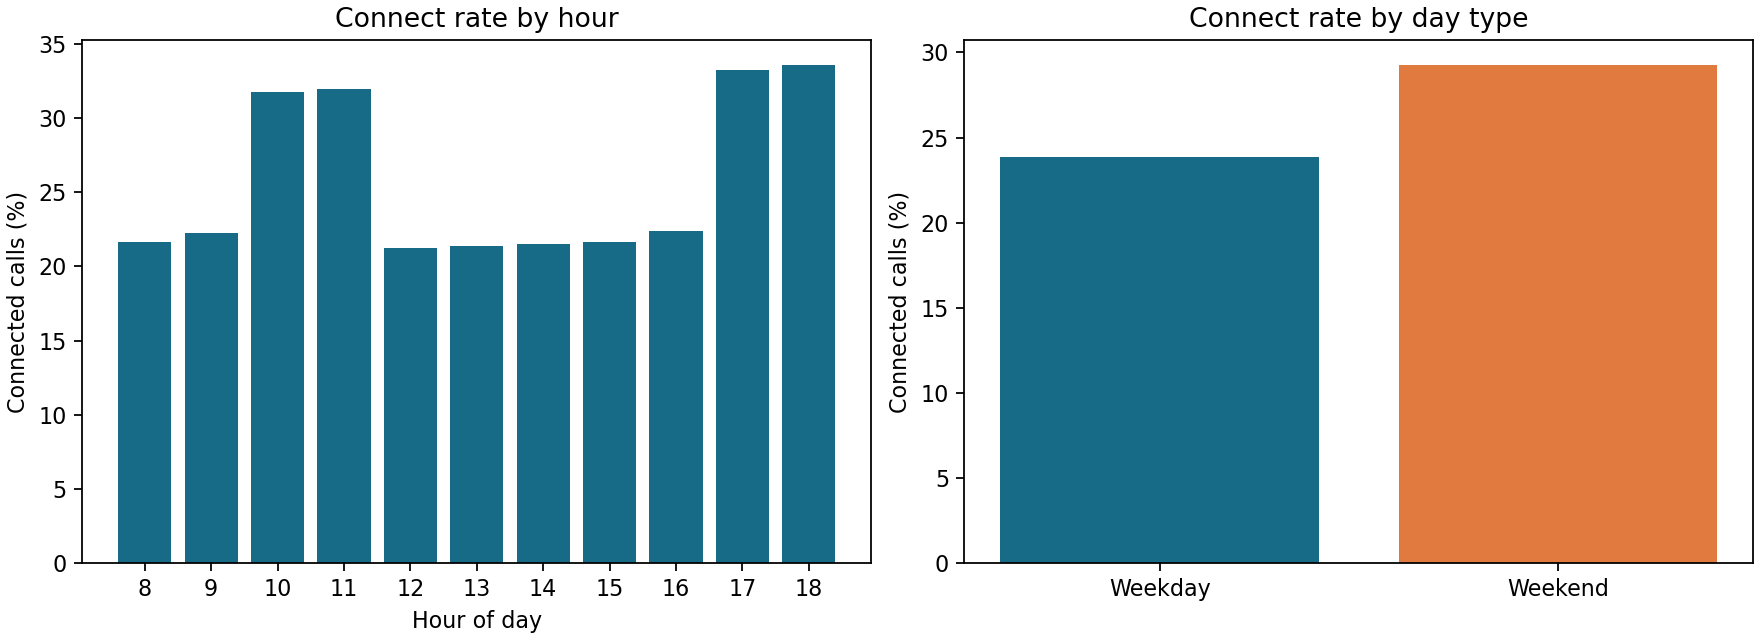

In [3]:
display(analysis['hourly'].assign(connect_rate=lambda table: table['connect_rate'].map(lambda rate: f'{rate:.1%}')))
display(analysis['weekpart'].assign(connect_rate=lambda table: table['connect_rate'].map(lambda rate: f'{rate:.1%}')))
output_dir = DATA_DIR / 'outputs'
output_dir.mkdir(exist_ok=True)
chart_path = output_dir / 'connect_rates.png'
save_connect_chart(analysis['hourly'], analysis['weekpart'], chart_path)
display(Image(filename=str(chart_path)))

## Promise performance

PTP rate is PTP calls divided by right-party contacts in each DPD band. Kept rate is the share of PTPs paid on time, grouped by days until the promised date.

In [4]:
display(analysis['dpd_rates'].assign(ptp_rate=lambda table: table['ptp_rate'].map(lambda rate: f'{rate:.1%}')))
display(analysis['keep_rates'].assign(kept_rate=lambda table: table['kept_rate'].map(lambda rate: f'{rate:.1%}')))

,dpd_band,rpc,ptp,ptp_rate
0,1-30,4094,1151,28.1%
1,31-60,4119,1055,25.6%
2,61-90,4199,900,21.4%
3,91-120,4104,786,19.2%


,days_to_promise,ptps,kept_rate
0,1,259,62.5%
1,2,280,69.3%
2,3,287,63.1%
3,4,306,61.4%
4,5,267,68.5%
5,6,266,31.6%
6,7,263,34.2%
7,8,257,34.2%
8,9,300,34.3%
9,10,308,34.1%


## Segment anomaly

Compare wrong-party contact among connected calls for Bihar batch B7 against all other connected calls. This identifies the injected state/batch issue without confusing it with the overall connection rate.

In [5]:
anomaly = analysis['anomaly']
print(f"B7 / BR: {anomaly['target_wrong']:,} wrong-party calls from {anomaly['target_connected']:,} connects ({anomaly['target_wrong_rate']:.1%})")
print(f"Other segments: {anomaly['baseline_wrong_rate']:.1%} wrong-party among connected calls")
print(f"Relative wrong-party rate: {anomaly['rate_ratio']:.1f}x")
print('Action: suppress this segment temporarily, audit number-to-borrower mapping, then resume with a controlled sample.')

B7 / BR: 114 wrong-party calls from 213 connects (53.5%)
Other segments: 7.8% wrong-party among connected calls
Relative wrong-party rate: 6.8x
Action: suppress this segment temporarily, audit number-to-borrower mapping, then resume with a controlled sample.


## Collections Head memo

The memo uses measured rates to quantify the expected effect per 1,000 comparable attempts and saves a copy under `outputs/collections_memo.md`.

In [6]:
memo_path = output_dir / 'collections_memo.md'
print(write_memo(analysis, memo_path))
print(f'Memo saved to {memo_path}')

# Collections Campaign Memo

**To:** Collections Head  
**Subject:** August dialer results and immediate actions

The generated sample contains 70,235 call attempts. All rates below are call-level estimates from this synthetic dataset; validate against production before changing lender policy.

1. **Time-weight capacity toward the strongest hour.** Hour 18:00 connected at 33.6%, versus 21.2% at 12:00. Moving 1,000 attempts from the weakest to strongest hour would imply about 123 additional connects, assuming comparable account mix and no saturation.
2. **Quarantine and audit batch B7 in Bihar.** 114 of 213 connects (53.5%) were wrong-party, against 7.8% elsewhere (6.8x). Pause or suppress this segment, validate phone mapping, then resume only after a controlled sample passes.
3. **Plan weekday/weekend staffing from measured lift.** Weekday connect rate was 23.8%; weekend was 29.3%. At 1,000 attempts, the observed difference corresponds to +54 connects on weekends. Run a balanced time/s